In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df =pd.read_csv('/content/HR_comma_sep.csv')

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.nunique()

,0
satisfaction_level,92
last_evaluation,65
number_project,6
average_montly_hours,215
time_spend_company,8
Work_accident,2
left,2
promotion_last_5years,2
Department,10
salary,3


In [ ]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


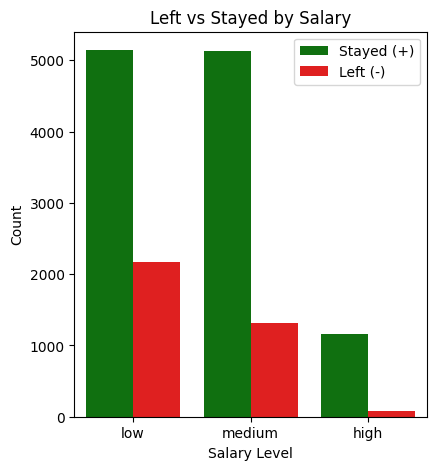

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='salary', hue='left', palette=['Green', 'Red'])
plt.title('Left vs Stayed by Salary')
plt.xlabel('Salary Level')
plt.ylabel('Count')
plt.legend(labels=['Stayed (+)', 'Left (-)'])

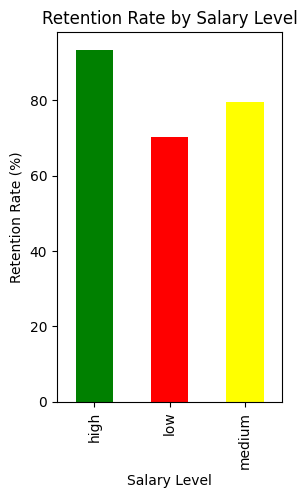

In [ ]:
plt.subplot(1, 2, 2)
retention_by_salary = df[df['left'] == 0].groupby('salary').size() / df.groupby('salary').size() * 100
retention_by_salary.plot(kind='bar', color=['green', 'red', 'yellow'])
plt.title('Retention Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Retention Rate (%)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Identify categorical columns
categorical_cols = ['Department', 'salary']

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Split features (X) and target (y)
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_test

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
6723,0.65,0.96,5,226,2,1,0,False,False,False,False,True,False,False,False,False,False,True
6473,0.88,0.80,3,166,2,0,0,False,False,False,False,False,False,False,False,False,True,False
4679,0.69,0.98,3,214,2,0,0,False,False,False,False,False,False,True,False,False,True,False
862,0.41,0.47,2,154,3,0,0,False,False,False,False,False,False,True,False,False,True,False
7286,0.87,0.76,5,254,2,1,0,False,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3297,0.61,0.74,2,143,6,0,0,False,False,False,False,False,False,True,False,False,False,True
14113,0.93,0.89,3,255,7,1,0,False,False,False,False,False,False,True,False,False,False,True
5514,0.78,0.61,3,193,3,0,0,False,False,False,False,False,False,True,False,False,False,True
9939,0.89,0.76,2,278,2,0,0,False,False,False,False,False,False,True,False,False,False,True


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model.predict(x_test)
model.score(x_test, y_test)

0.7903333333333333

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])